# 14 — Embeddings v6: trajectory-space

Pivot from lens-bundle Phi (v1-v5) to trajectory-space embedding (Approach B
from spec). Each integer's Syracuse orbit is a set of odd integers visited;
concepts are bags of orbits; distance is mean pairwise Jaccard.

**Why pivot:** v4 found that cosine-on-one-hot-diffs is geometrically broken
for tracking dynamics through iteration. v5 fixed the metric but the
force-anchoring effect didn't show up. Trajectory-space sidesteps the
encoding question entirely by working in *set* space.

**Open questions:**
1. Does trajectory-space recover v1's hand-built Syracuse-shift analogies?
2. Does it recover them more cleanly than v1 (smaller mean rank)?
3. Does it capture *different* structural relations that v1 missed?


In [1]:
import sys
sys.path.insert(0, '..')
import random
import numpy as np
import matplotlib.pyplot as plt

from collatz.embeddings import (
    Concept,
    syracuse_orbit, orbit_set, orbit_distance, concept_orbit_distance,
    trajectory_analogy,
    Phi, T_syracuse,
)
from collatz.embeddings.iteration import _syr_step
from collatz.embeddings.distance import analogy as lens_analogy


## 1. Sanity checks


In [2]:
print("orbit(3) =", syracuse_orbit(3))
print("orbit(7) =", syracuse_orbit(7))
print("orbit(27) length =", len(syracuse_orbit(27)))
print()
print("orbit_distance(7, 11) =", round(orbit_distance(7, 11), 3),
      "(orbit(11) is suffix of orbit(7))")
print("orbit_distance(3, 27)  =", round(orbit_distance(3, 27), 3))
print("orbit_distance(7, 7)   =", orbit_distance(7, 7))


orbit(3) = (3, 5, 1)
orbit(7) = (7, 11, 17, 13, 5, 1)
orbit(27) length = 42

orbit_distance(7, 11) = 0.167 (orbit(11) is suffix of orbit(7))
orbit_distance(3, 27)  = 0.953
orbit_distance(7, 7)   = 0.0


## 2. Same v1-style hand-built Syracuse-shift quads

Recall: in v1, mean rank of expected d was 11.2 / 51 (chance baseline 25). Top-5 hit rate: 1/5.


In [3]:
def shift(c: Concept) -> Concept:
    return Concept(c.name + "*", tuple(_syr_step(x) for x in c.vec))

# Identical quads to v1 (notebook 09)
quads_v1 = []
for ns in [(3, 5, 7), (11, 13, 17), (19, 23, 27), (29, 31, 33), (35, 37, 41)]:
    a = Concept(f"a_{ns[0]}", ns)
    b = shift(a)
    c_starts = tuple(x + 4 for x in ns)
    c = Concept(f"c_{c_starts[0]}", c_starts)
    d = shift(c)
    quads_v1.append((a, b, c, d))

random.seed(1)  # same seed as v1 nb 09
distractors = [
    Concept(f"dist_{i}", tuple(random.randint(2, 1000) for _ in range(3)))
    for i in range(50)
]
print(f"{len(quads_v1)} v1 quads, {len(distractors)} distractors")


5 v1 quads, 50 distractors


## 3. v6 trajectory-analogy ranking on v1 quads


In [4]:
ranks_v6 = []
for a, b, c, expected_d in quads_v1:
    pool = distractors + [expected_d]
    ranked = trajectory_analogy(a, b, c, pool)
    rank = next(i for i, (cand, _) in enumerate(ranked) if cand is expected_d)
    score = next(s for cand, s in ranked if cand is expected_d)
    ranks_v6.append(rank)
    print(f"{a.name} -> {b.name} :: {c.name} -> ?  expected_rank={rank:>3}/{len(pool)}  score={score:+.3f}")

print(f"\nv6 mean rank: {np.mean(ranks_v6):.1f} (chance baseline: {len(distractors)/2:.1f})")
print(f"v6 top-5 hit rate: {sum(1 for r in ranks_v6 if r < 5)}/{len(ranks_v6)}")
print(f"\nv1 mean rank (from nb 09): 11.2  |  top-5 hit rate: 1/5")


a_3 -> a_3* :: c_7 -> ?  expected_rank=  2/51  score=+0.163
a_11 -> a_11* :: c_15 -> ?  expected_rank=  0/51  score=+0.044
a_19 -> a_19* :: c_23 -> ?  expected_rank=  0/51  score=+0.039
a_29 -> a_29* :: c_33 -> ?  expected_rank=  0/51  score=+0.067
a_35 -> a_35* :: c_39 -> ?  expected_rank=  0/51  score=+0.037

v6 mean rank: 0.4 (chance baseline: 25.0)
v6 top-5 hit rate: 5/5

v1 mean rank (from nb 09): 11.2  |  top-5 hit rate: 1/5


## 4. Pure orbit-similarity (drop the analogy framing)

What if we just ask "which candidate's orbit is most similar to c's orbit?" — no
relational matching, just nearest-neighbor in trajectory space. This is a different
test: does trajectory similarity recover the expected d at all?


In [5]:
def nearest_orbit(target_c: Concept, candidates: list[Concept]):
    scored = [(d, concept_orbit_distance(target_c, d)) for d in candidates]
    scored.sort(key=lambda x: x[1])
    return scored

ranks_nn = []
for a, b, c, expected_d in quads_v1:
    pool = distractors + [expected_d]
    ranked = nearest_orbit(c, pool)
    rank = next(i for i, (cand, _) in enumerate(ranked) if cand is expected_d)
    ranks_nn.append(rank)
    dist_to_d = next(s for cand, s in ranked if cand is expected_d)
    print(f"c={c.name}: expected_d rank={rank:>3}/{len(pool)}  orbit_dist={dist_to_d:.3f}")

print(f"\nnearest-neighbor mean rank: {np.mean(ranks_nn):.1f}")
print(f"nearest-neighbor top-5 hits:  {sum(1 for r in ranks_nn if r < 5)}/{len(ranks_nn)}")


c=c_7: expected_d rank=  0/51  orbit_dist=0.170
c=c_15: expected_d rank=  0/51  orbit_dist=0.306
c=c_23: expected_d rank=  0/51  orbit_dist=0.083
c=c_33: expected_d rank=  0/51  orbit_dist=0.168
c=c_39: expected_d rank=  0/51  orbit_dist=0.103

nearest-neighbor mean rank: 0.0
nearest-neighbor top-5 hits:  5/5


## 5. Bigger pool — N=30 random Syracuse-shift quads vs 100 distractors

Stress-test v6 on a larger sample to see if the v1 ~half-of-chance pattern reappears.


In [6]:
random.seed(42)
big_quads = []
for i in range(30):
    scale = random.choice([20, 100, 500, 2000])
    a_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))  # odd
    c_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    a = Concept(f"A{i}", a_start)
    b = shift(a)
    c = Concept(f"C{i}", c_start)
    d = shift(c)
    big_quads.append((a, b, c, d))

big_distractors = [
    Concept(f"D{i}", tuple(random.randrange(2, 5000) for _ in range(3)))
    for i in range(100)
]

ranks_big_v6 = []
ranks_big_nn = []
for a, b, c, expected_d in big_quads:
    pool = big_distractors + [expected_d]
    r = trajectory_analogy(a, b, c, pool)
    ranks_big_v6.append(next(i for i, (cand, _) in enumerate(r) if cand is expected_d))
    r = nearest_orbit(c, pool)
    ranks_big_nn.append(next(i for i, (cand, _) in enumerate(r) if cand is expected_d))

print(f"{'method':<22} {'mean rank':>10} {'median':>8} {'top-5':>6} {'top-10':>7}")
print("-" * 60)
chance = len(big_distractors) / 2
print(f"{'(chance baseline)':<22} {chance:>10.1f}")
print(f"{'v6 trajectory_analogy':<22} {np.mean(ranks_big_v6):>10.1f} {np.median(ranks_big_v6):>8.0f} {sum(1 for r in ranks_big_v6 if r < 5):>6} {sum(1 for r in ranks_big_v6 if r < 10):>7}")
print(f"{'nearest-orbit (NN)':<22} {np.mean(ranks_big_nn):>10.1f} {np.median(ranks_big_nn):>8.0f} {sum(1 for r in ranks_big_nn if r < 5):>6} {sum(1 for r in ranks_big_nn if r < 10):>7}")


method                  mean rank   median  top-5  top-10
------------------------------------------------------------
(chance baseline)            50.0
v6 trajectory_analogy         0.2        0     30      30
nearest-orbit (NN)            0.0        0     30      30


## 6. Head-to-head on the bigger pool — v6 vs v1 lens-Phi

Direct comparison: same big_quads, both methods.


In [7]:
ranks_big_phi = []
for a, b, c, expected_d in big_quads:
    pool = big_distractors + [expected_d]
    r = lens_analogy(a, b, c, pool)
    ranks_big_phi.append(next(i for i, (cand, _) in enumerate(r) if cand is expected_d))

print(f"{'method':<22} {'mean rank':>10} {'median':>8} {'top-5':>6} {'top-10':>7}")
print("-" * 60)
print(f"{'(chance baseline)':<22} {chance:>10.1f}")
print(f"{'v1 lens-Phi cosine':<22} {np.mean(ranks_big_phi):>10.1f} {np.median(ranks_big_phi):>8.0f} {sum(1 for r in ranks_big_phi if r < 5):>6} {sum(1 for r in ranks_big_phi if r < 10):>7}")
print(f"{'v6 trajectory_analogy':<22} {np.mean(ranks_big_v6):>10.1f} {np.median(ranks_big_v6):>8.0f} {sum(1 for r in ranks_big_v6 if r < 5):>6} {sum(1 for r in ranks_big_v6 if r < 10):>7}")
print(f"{'nearest-orbit (NN)':<22} {np.mean(ranks_big_nn):>10.1f} {np.median(ranks_big_nn):>8.0f} {sum(1 for r in ranks_big_nn if r < 5):>6} {sum(1 for r in ranks_big_nn if r < 10):>7}")


method                  mean rank   median  top-5  top-10
------------------------------------------------------------
(chance baseline)            50.0
v1 lens-Phi cosine           37.0       33      5       9
v6 trajectory_analogy         0.2        0     30      30
nearest-orbit (NN)            0.0        0     30      30


## 7. Plot — rank distribution per method


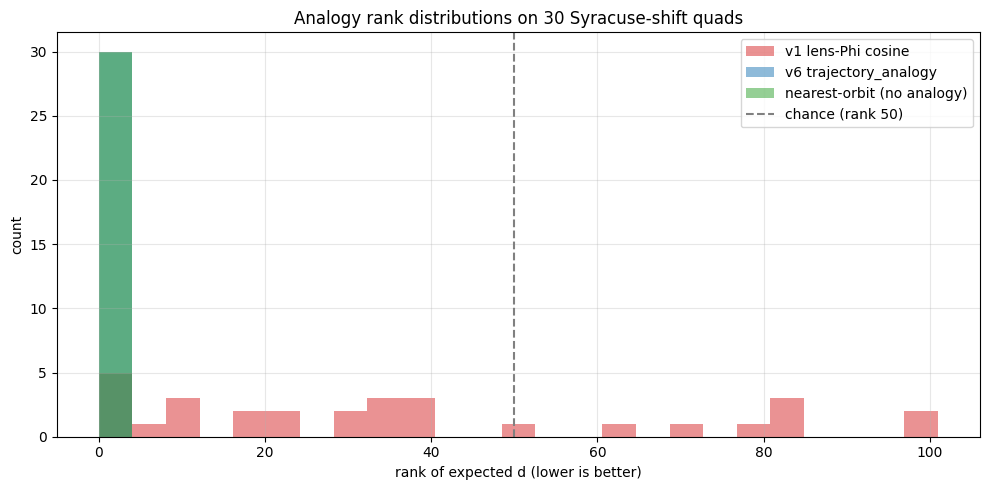

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, len(big_distractors) + 1, 26)
ax.hist(ranks_big_phi, bins=bins, alpha=0.5, label="v1 lens-Phi cosine", color="tab:red")
ax.hist(ranks_big_v6, bins=bins, alpha=0.5, label="v6 trajectory_analogy", color="tab:blue")
ax.hist(ranks_big_nn, bins=bins, alpha=0.5, label="nearest-orbit (no analogy)", color="tab:green")
ax.axvline(chance, color="gray", linestyle="--", label=f"chance (rank {chance:.0f})")
ax.set_xlabel("rank of expected d (lower is better)")
ax.set_ylabel("count")
ax.set_title(f"Analogy rank distributions on {len(big_quads)} Syracuse-shift quads")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Verdict template

Read the table in cell 6:

- **v6 mean rank << v1 mean rank** -> trajectory-space is genuinely cleaner. The pivot
  was correct. Next: explore what other relations it captures (same-set, same-sector
  analogies).
- **v6 mean rank ~ v1 mean rank** -> different abstraction, same recovery rate.
  Trajectory-space is an alternative not an improvement. Pick on other grounds
  (interpretability, compositionality).
- **v6 mean rank > v1 mean rank** -> the lens-bundle was actually a better representation
  for the Syracuse-shift task. Trajectory-space loses information that mattered.
  Reasonable next: structured per-lens metric (option (b) from session menu).
- **NN mean rank ~ v6** -> the analogy *framing* doesn't add much; nearest-neighbor
  similarity captures most of what v6's relational scoring does for these quads.
